# 06a — CLEAR Peptide VAE Training

## VAE extension — separata dalla Pipeline 2 consolidata

Questo notebook implementa un **vero Variational Autoencoder (VAE)** sul dataset locale 04c. La Pipeline 2 consolidata resta invariata.

Nuovo ramo sperimentale:

```text
06a VAE training
→ 06b latent-space analysis
→ 06c latent counterfactual optimization
→ 06d VAE-CLEAR vs Direct CLEAR
```

Il VAE impara una rappresentazione continua:

\[
x \rightarrow q_\phi(z|x) \rightarrow z \rightarrow p_\theta(x|z)
\]

con encoder, reparameterization trick, KL divergence e decoder categoriale. Il dataset è piccolo (~539 sequenze), quindi il modello è intenzionalmente compatto e include controlli anti-collapse.

In [1]:
from pathlib import Path
import json, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
print("PyTorch:", torch.__version__)

PyTorch: 2.2.1


## 1. Configurazione

In [2]:
OUTPUT_DIR = Path("outputs")
DATASET_CANDIDATES = [
    OUTPUT_DIR / "clear_local_peptide_dataset_04c" / "clear_local_peptide_variant_dataset_labeled.csv",
    OUTPUT_DIR / "clear_local_peptide_dataset_04c" / "clear_local_peptide_variant_dataset.csv",
]
RESULT_DIR = OUTPUT_DIR / "clear_peptide_vae_06a"
MODEL_DIR = RESULT_DIR / "models"
REPORTS_DIR = RESULT_DIR / "reports"
for d in [RESULT_DIR, MODEL_DIR, REPORTS_DIR]: d.mkdir(parents=True, exist_ok=True)
SEED_SEQUENCE = "IGERCQYRDLK"
AA_ALPHABET = list("ACDEFGHIKLMNPQRSTVWY")
AA_TO_IDX = {aa:i for i,aa in enumerate(AA_ALPHABET)}
IDX_TO_AA = {i:aa for aa,i in AA_TO_IDX.items()}
SEQ_LEN=len(SEED_SEQUENCE); N_AA=len(AA_ALPHABET)
RANDOM_SEED=42
EMBED_DIM=12; HIDDEN_DIM=64; LATENT_DIM=4
BETA_KL=0.05; LEARNING_RATE=1e-3; BATCH_SIZE=64; MAX_EPOCHS=400; PATIENCE=40
DEVICE=(torch.device("mps") if torch.backends.mps.is_available() else torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)
print("Device:", DEVICE)

Device: mps


## 2. Dataset 04c

In [3]:
def first_existing(paths):
    for p in paths:
        if p.exists(): return p
    return None
DATASET_PATH=first_existing(DATASET_CANDIDATES)
if DATASET_PATH is None:
    matches=sorted(OUTPUT_DIR.rglob("*clear*variant*dataset*.csv"))
    if not matches: raise FileNotFoundError("Dataset 04c non trovato")
    DATASET_PATH=matches[0]
dataset=pd.read_csv(DATASET_PATH)
sequence_column=next((c for c in ["sequence","mutant_sequence","variant_sequence","peptide_sequence"] if c in dataset.columns),None)
if sequence_column is None: raise ValueError("Colonna sequenza non riconosciuta")
dataset[sequence_column]=dataset[sequence_column].astype(str).str.strip().str.upper()
dataset=dataset[dataset[sequence_column].str.len()==SEQ_LEN].copy()
dataset=dataset[dataset[sequence_column].apply(lambda s: all(a in AA_TO_IDX for a in s))]
dataset=dataset.drop_duplicates(subset=[sequence_column]).reset_index(drop=True)
print("Dataset:", DATASET_PATH.resolve())
print("Sequenze valide uniche:", len(dataset))
print("Seed presente:", SEED_SEQUENCE in set(dataset[sequence_column]))

Dataset: /Users/robertobruzzese/Desktop/venv/outputs/clear_local_peptide_dataset_04c/clear_local_peptide_variant_dataset_labeled.csv
Sequenze valide uniche: 539
Seed presente: True


In [ ]:
def hamming(a,b): return sum(x!=y for x,y in zip(a,b))
dataset["hamming_to_seed"]=dataset[sequence_column].apply(lambda s:hamming(s,SEED_SEQUENCE))
display(dataset["hamming_to_seed"].value_counts().sort_index().rename_axis("n_mutations").to_frame("count"))

In [5]:
def hamming_distance(seq_a, seq_b):
    return sum(
        aa != bb
        for aa, bb in zip(seq_a, seq_b)
    )


dataset["hamming_to_seed"] = (
    dataset[sequence_column]
    .apply(
        lambda seq: hamming_distance(
            seq,
            SEED_SEQUENCE,
        )
    )
)

display(
    dataset[
        [sequence_column, "hamming_to_seed"]
    ].head()
)

print(
    dataset["hamming_to_seed"]
    .value_counts()
    .sort_index()
)

,sequence,hamming_to_seed
0,IGERCQYRDLK,0
1,AGERCQYRDLK,1
2,FGERCQYRDLK,1
3,LGERCQYRDLK,1
4,MGERCQYRDLK,1


hamming_to_seed
0      1
1     38
2    500
Name: count, dtype: int64


## 3. Split train / validation / test

In [6]:
seed_rows=dataset[dataset[sequence_column]==SEED_SEQUENCE].copy()
other=dataset[dataset[sequence_column]!=SEED_SEQUENCE].copy()
train_other,temp=train_test_split(other,test_size=0.30,random_state=RANDOM_SEED,stratify=other["hamming_to_seed"])
val_df,test_df=train_test_split(temp,test_size=0.50,random_state=RANDOM_SEED,stratify=temp["hamming_to_seed"])
train_df=pd.concat([seed_rows,train_other],ignore_index=True)
print("Train/Val/Test:",len(train_df),len(val_df),len(test_df))

Train/Val/Test: 377 81 81


## 4. Encoding categoriale

In [7]:
def encode_sequence(s): return np.array([AA_TO_IDX[a] for a in s],dtype=np.int64)
def decode_indices(x): return "".join(IDX_TO_AA[int(i)] for i in x)
class PeptideDataset(Dataset):
    def __init__(self,df): self.arr=np.stack([encode_sequence(s) for s in df[sequence_column]])
    def __len__(self): return len(self.arr)
    def __getitem__(self,i): return torch.tensor(self.arr[i],dtype=torch.long)
train_loader=DataLoader(PeptideDataset(train_df),batch_size=BATCH_SIZE,shuffle=True)
val_loader=DataLoader(PeptideDataset(val_df),batch_size=BATCH_SIZE)
test_loader=DataLoader(PeptideDataset(test_df),batch_size=BATCH_SIZE)

## 5. Architettura VAE

In [8]:
class PeptideVAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding=nn.Embedding(N_AA,EMBED_DIM)
        self.encoder=nn.Sequential(nn.Linear(SEQ_LEN*EMBED_DIM,HIDDEN_DIM),nn.ReLU(),nn.LayerNorm(HIDDEN_DIM),nn.Linear(HIDDEN_DIM,HIDDEN_DIM//2),nn.ReLU())
        self.mu_head=nn.Linear(HIDDEN_DIM//2,LATENT_DIM)
        self.logvar_head=nn.Linear(HIDDEN_DIM//2,LATENT_DIM)
        self.decoder=nn.Sequential(nn.Linear(LATENT_DIM,HIDDEN_DIM//2),nn.ReLU(),nn.Linear(HIDDEN_DIM//2,HIDDEN_DIM),nn.ReLU(),nn.Linear(HIDDEN_DIM,SEQ_LEN*N_AA))
    def encode(self,x):
        h=self.encoder(self.embedding(x).reshape(x.size(0),-1)); return self.mu_head(h),self.logvar_head(h)
    def reparameterize(self,mu,logvar): return mu+torch.randn_like(mu)*torch.exp(0.5*logvar)
    def decode(self,z): return self.decoder(z).reshape(z.size(0),SEQ_LEN,N_AA)
    def forward(self,x):
        mu,logvar=self.encode(x); z=self.reparameterize(mu,logvar); return self.decode(z),mu,logvar,z
model=PeptideVAE().to(DEVICE)
print(model)
print("Parametri:",sum(p.numel() for p in model.parameters() if p.requires_grad))

PeptideVAE(
  (embedding): Embedding(20, 12)
  (encoder): Sequential(
    (0): Linear(in_features=132, out_features=64, bias=True)
    (1): ReLU()
    (2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
  )
  (mu_head): Linear(in_features=32, out_features=4, bias=True)
  (logvar_head): Linear(in_features=32, out_features=4, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=220, bias=True)
  )
)
Parametri: 27796


## 6. Loss

\[
L = L_{reconstruction} + \beta L_{KL}
\]


In [9]:
def vae_loss(logits,target,mu,logvar):
    rec=F.cross_entropy(logits.reshape(-1,N_AA),target.reshape(-1),reduction="mean")
    kl=-0.5*torch.mean(torch.sum(1+logvar-mu.pow(2)-logvar.exp(),dim=1))
    return rec+BETA_KL*kl,rec,kl

def run_epoch(loader,optimizer=None):
    training=optimizer is not None; model.train(training)
    sums={"loss":0.,"rec":0.,"kl":0.,"res_ok":0,"res_n":0,"seq_ok":0,"seq_n":0}
    for batch in loader:
        batch=batch.to(DEVICE)
        if training: optimizer.zero_grad()
        with torch.set_grad_enabled(training):
            logits,mu,logvar,_=model(batch); loss,rec,kl=vae_loss(logits,batch,mu,logvar)
            if training:
                loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),5.0); optimizer.step()
        pred=logits.argmax(-1); n=len(batch)
        sums["loss"]+=loss.item()*n; sums["rec"]+=rec.item()*n; sums["kl"]+=kl.item()*n
        sums["res_ok"]+=(pred==batch).sum().item(); sums["res_n"]+=batch.numel(); sums["seq_ok"]+=(pred==batch).all(1).sum().item(); sums["seq_n"]+=n
    n=len(loader.dataset)
    return {"loss":sums["loss"]/n,"reconstruction":sums["rec"]/n,"kl":sums["kl"]/n,"residue_accuracy":sums["res_ok"]/sums["res_n"],"sequence_accuracy":sums["seq_ok"]/sums["seq_n"]}

## 7. Training

In [10]:
optimizer=torch.optim.Adam(model.parameters(),lr=LEARNING_RATE)
history=[]; best_val=float("inf"); best_state=None; stale=0
for epoch in range(1,MAX_EPOCHS+1):
    tr=run_epoch(train_loader,optimizer); va=run_epoch(val_loader)
    history.append({"epoch":epoch,**{f"train_{k}":v for k,v in tr.items()},**{f"val_{k}":v for k,v in va.items()}})
    if va["loss"]<best_val-1e-5:
        best_val=va["loss"]; best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}; stale=0
    else: stale+=1
    if epoch==1 or epoch%20==0: print(f"{epoch:03d} | train={tr['loss']:.4f} | val={va['loss']:.4f} | val_acc={va['residue_accuracy']:.3f} | KL={va['kl']:.4f}")
    if stale>=PATIENCE:
        print("Early stopping:",epoch); break
history_df=pd.DataFrame(history)
model.load_state_dict(best_state); model=model.to(DEVICE)

001 | train=2.9491 | val=2.8902 | val_acc=0.301 | KL=0.0255
020 | train=0.7431 | val=0.7694 | val_acc=0.824 | KL=0.5404
040 | train=0.6775 | val=0.7048 | val_acc=0.824 | KL=0.0189
060 | train=0.6723 | val=0.7004 | val_acc=0.824 | KL=0.0133
080 | train=0.6686 | val=0.6977 | val_acc=0.824 | KL=0.0209
100 | train=0.6661 | val=0.6930 | val_acc=0.824 | KL=0.0661
120 | train=0.6576 | val=0.6695 | val_acc=0.824 | KL=0.3509
140 | train=0.6424 | val=0.6810 | val_acc=0.825 | KL=0.7944
160 | train=0.6383 | val=0.6590 | val_acc=0.826 | KL=0.9824
180 | train=0.6202 | val=0.6725 | val_acc=0.829 | KL=1.2333
200 | train=0.6098 | val=0.6520 | val_acc=0.838 | KL=1.4358
220 | train=0.6019 | val=0.6438 | val_acc=0.841 | KL=1.8417
240 | train=0.5810 | val=0.6347 | val_acc=0.834 | KL=2.1229
260 | train=0.5742 | val=0.6331 | val_acc=0.840 | KL=2.3652
280 | train=0.5598 | val=0.6197 | val_acc=0.840 | KL=2.5466
300 | train=0.5503 | val=0.6263 | val_acc=0.845 | KL=2.5930
320 | train=0.5458 | val=0.6260 | val_ac

## 8. Curve e valutazione

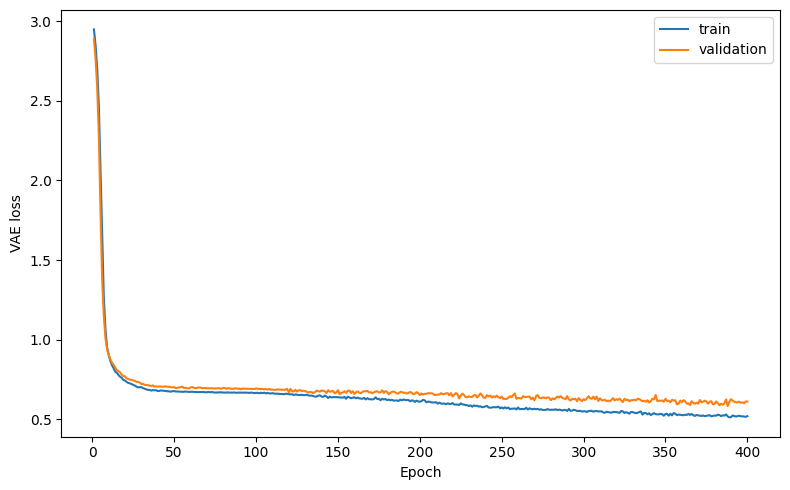

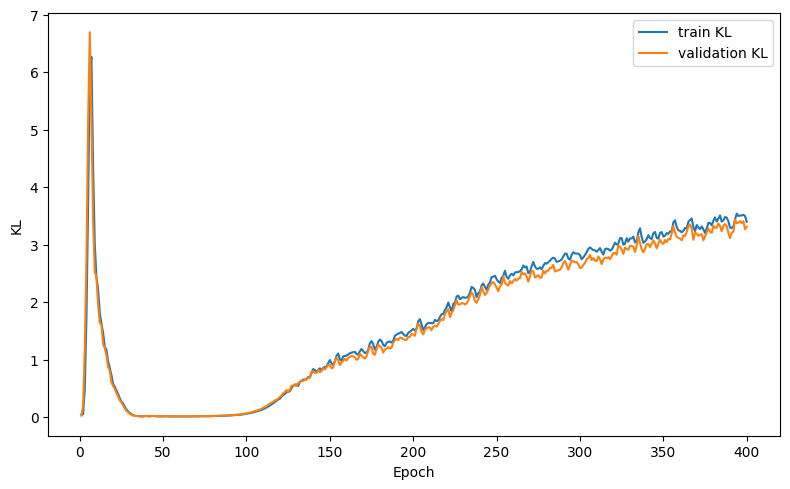

In [11]:
plt.figure(figsize=(8,5)); plt.plot(history_df.epoch,history_df.train_loss,label="train"); plt.plot(history_df.epoch,history_df.val_loss,label="validation"); plt.xlabel("Epoch"); plt.ylabel("VAE loss"); plt.legend(); plt.tight_layout(); plt.show()
plt.figure(figsize=(8,5)); plt.plot(history_df.epoch,history_df.train_kl,label="train KL"); plt.plot(history_df.epoch,history_df.val_kl,label="validation KL"); plt.xlabel("Epoch"); plt.ylabel("KL"); plt.legend(); plt.tight_layout(); plt.show()

In [12]:
train_final=run_epoch(train_loader); val_final=run_epoch(val_loader); test_final=run_epoch(test_loader)
evaluation_df=pd.DataFrame([{"split":"train",**train_final},{"split":"validation",**val_final},{"split":"test",**test_final}])
display(evaluation_df)

,split,loss,reconstruction,kl,residue_accuracy,sequence_accuracy
0,train,0.523343,0.350994,3.446970,0.868821,0.098143
1,validation,0.597695,0.431629,3.321329,0.845118,0.012346
2,test,0.593893,0.429562,3.286639,0.845118,0.012346


## 9. Ricostruzione del seed F0010

In [14]:
@torch.no_grad()
def reconstruct(sequence):
    x = torch.tensor(
        encode_sequence(sequence),
        dtype=torch.long
    ).unsqueeze(0).to(DEVICE)

    mu, logvar = model.encode(x)
    logits = model.decode(mu)

    rec = decode_indices(
        logits.argmax(-1)[0].cpu().numpy()
    )

    return (
        rec,
        hamming_distance(sequence, rec),
        mu[0].cpu().numpy(),
        logvar[0].cpu().numpy()
    )


seed_rec, seed_h, seed_mu, seed_logvar = reconstruct(SEED_SEQUENCE)

print("Input:", SEED_SEQUENCE)
print("Reconstruction:", seed_rec)
print("Hamming error:", seed_h)

Input: IGERCQYRDLK
Reconstruction: IGERCQYRDLK
Hamming error: 0


## 10. Latent embeddings e anti-collapse

In [15]:
@torch.no_grad()
def encode_many(seqs):
    x=torch.tensor(np.stack([encode_sequence(s) for s in seqs]),dtype=torch.long).to(DEVICE)
    mu,logvar=model.encode(x); return mu.cpu().numpy(),logvar.cpu().numpy()
latent_mu,latent_logvar=encode_many(dataset[sequence_column].tolist())
latent_df=dataset[[sequence_column,"hamming_to_seed"]].copy()
for j in range(LATENT_DIM): latent_df[f"z{j+1}"]=latent_mu[:,j]
latent_diag=pd.DataFrame({"dimension":[f"z{i+1}" for i in range(LATENT_DIM)],"mean":latent_mu.mean(0),"std":latent_mu.std(0),"min":latent_mu.min(0),"max":latent_mu.max(0),"mean_logvar":latent_logvar.mean(0)})
display(latent_diag)
print("Mean latent std:",float(latent_mu.std(0).mean()))

,dimension,mean,std,min,max,mean_logvar
0,z1,0.132352,0.942244,-1.792933,2.031049,-1.938749
1,z2,-0.132072,0.738938,-2.110866,1.317378,-0.883613
2,z3,-0.089882,0.918288,-1.997395,2.300622,-1.806732
3,z4,-0.105238,0.908834,-2.287415,2.344784,-2.144177


Mean latent std: 0.877076268196106


## 11. PCA del latent space

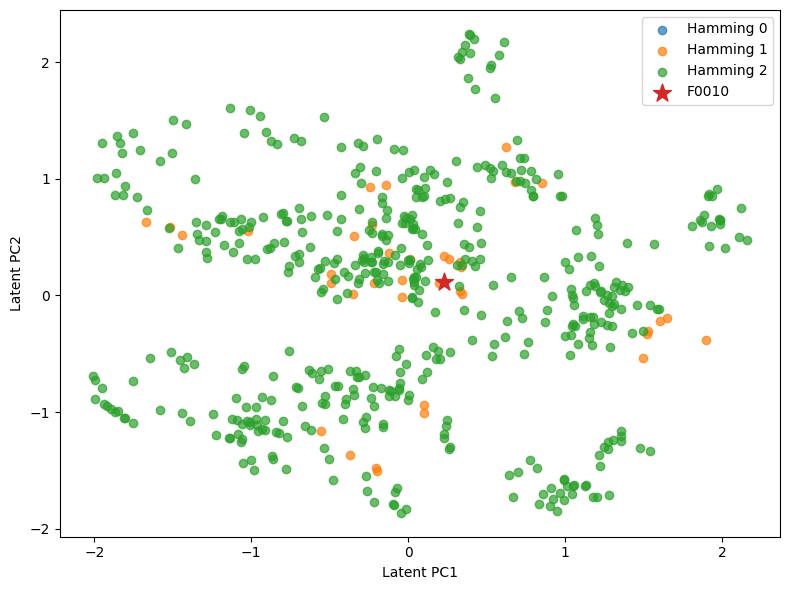

Explained variance: [0.29157978 0.27005503]


In [16]:
pca=PCA(n_components=2); xy=pca.fit_transform(latent_mu); latent_df["pc1"]=xy[:,0]; latent_df["pc2"]=xy[:,1]
plt.figure(figsize=(8,6))
for d in sorted(latent_df.hamming_to_seed.unique()):
    s=latent_df[latent_df.hamming_to_seed==d]; plt.scatter(s.pc1,s.pc2,label=f"Hamming {d}",alpha=.7)
seedp=latent_df[latent_df[sequence_column]==SEED_SEQUENCE]; plt.scatter(seedp.pc1,seedp.pc2,s=180,marker="*",label="F0010")
plt.xlabel("Latent PC1"); plt.ylabel("Latent PC2"); plt.legend(); plt.tight_layout(); plt.show()
print("Explained variance:",pca.explained_variance_ratio_)

## 12. Perturbazioni locali attorno al seed

In [18]:
@torch.no_grad()
def decode_z(z):
    z=torch.tensor(z,dtype=torch.float32,device=DEVICE).reshape(1,-1); return decode_indices(model.decode(z).argmax(-1)[0].cpu().numpy())
rows=[]
seen=set(dataset[sequence_column])
for scale in [0.05,0.10,0.20,0.30,0.50]:
    for _ in range(50):
        seq=decode_z(seed_mu+np.random.normal(0,scale,size=LATENT_DIM))
        rows.append({
            "scale": scale,
            "sequence": seq,
            "hamming_to_seed": hamming_distance(seq, SEED_SEQUENCE),
            "seen_in_04c": seq in seen
        })
local_samples_df=pd.DataFrame(rows)
display(local_samples_df.groupby("scale").agg(n_samples=("sequence","size"),n_unique=("sequence","nunique"),mean_hamming=("hamming_to_seed","mean"),max_hamming=("hamming_to_seed","max"),fraction_seen_04c=("seen_in_04c","mean")))

,n_samples,n_unique,mean_hamming,max_hamming,fraction_seen_04c
scale,,,,,
0.05,50,2,0.12,1,1.0
0.10,50,2,0.18,1,1.0
0.20,50,5,0.46,2,1.0
0.30,50,5,0.56,1,1.0
0.50,50,17,0.90,2,1.0


## 13. Quality checks

In [19]:
mean_latent_std=float(latent_mu.std(0).mean())
quality=pd.DataFrame([
    {"check":"seed reconstruction Hamming <= 1","passed":seed_h<=1,"value":seed_h},
    {"check":"test residue accuracy >= 0.90","passed":test_final["residue_accuracy"]>=0.90,"value":test_final["residue_accuracy"]},
    {"check":"KL not collapsed","passed":test_final["kl"]>1e-3,"value":test_final["kl"]},
    {"check":"latent std > 0.01","passed":mean_latent_std>1e-2,"value":mean_latent_std},
])
display(quality)
VAE_ACCEPTABLE_FOR_06B=bool(quality.passed.all())
print("VAE acceptable for 06b:",VAE_ACCEPTABLE_FOR_06B)

,check,passed,value
0,seed reconstruction Hamming <= 1,True,0.000000
1,test residue accuracy >= 0.90,False,0.845118
2,KL not collapsed,True,3.286639
3,latent std > 0.01,True,0.877076


VAE acceptable for 06b: False


## 14. Esportazione

In [20]:
MODEL_PATH=MODEL_DIR/"clear_peptide_vae.pt"
CONFIG_PATH=MODEL_DIR/"clear_peptide_vae_config.json"
LATENT_CSV=RESULT_DIR/"vae_latent_embeddings.csv"
HISTORY_CSV=RESULT_DIR/"vae_training_history.csv"
EVALUATION_CSV=RESULT_DIR/"vae_evaluation.csv"
QUALITY_CSV=RESULT_DIR/"vae_quality_checks.csv"
LOCAL_CSV=RESULT_DIR/"vae_local_seed_perturbations.csv"
torch.save({"model_state_dict":model.state_dict(),"seq_len":SEQ_LEN,"n_aa":N_AA,"embed_dim":EMBED_DIM,"hidden_dim":HIDDEN_DIM,"latent_dim":LATENT_DIM,"aa_alphabet":AA_ALPHABET,"seed_sequence":SEED_SEQUENCE},MODEL_PATH)
config={"dataset":str(DATASET_PATH),"sequence_column":sequence_column,"n_sequences":len(dataset),"seed_sequence":SEED_SEQUENCE,"embed_dim":EMBED_DIM,"hidden_dim":HIDDEN_DIM,"latent_dim":LATENT_DIM,"beta_kl":BETA_KL,"best_validation_loss":float(best_val),"seed_reconstruction":seed_rec,"seed_reconstruction_hamming":int(seed_h),"vae_acceptable_for_06b":VAE_ACCEPTABLE_FOR_06B}
CONFIG_PATH.write_text(json.dumps(config,indent=2),encoding="utf-8")
latent_df.to_csv(LATENT_CSV,index=False); history_df.to_csv(HISTORY_CSV,index=False); evaluation_df.to_csv(EVALUATION_CSV,index=False); quality.to_csv(QUALITY_CSV,index=False); local_samples_df.to_csv(LOCAL_CSV,index=False)
for p in [MODEL_PATH,CONFIG_PATH,LATENT_CSV,HISTORY_CSV,EVALUATION_CSV,QUALITY_CSV,LOCAL_CSV]: print("Salvato:",p.resolve())

Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_vae_06a/models/clear_peptide_vae.pt
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_vae_06a/models/clear_peptide_vae_config.json
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_vae_06a/vae_latent_embeddings.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_vae_06a/vae_training_history.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_vae_06a/vae_evaluation.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_vae_06a/vae_quality_checks.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_vae_06a/vae_local_seed_perturbations.csv


## 15. Report e passaggio successivo

In [21]:
report=f"""# 06a — CLEAR Peptide VAE Training

Dataset: {len(dataset)} sequenze
Seed: {SEED_SEQUENCE}
Latent dimension: {LATENT_DIM}
Beta KL: {BETA_KL}
Test residue accuracy: {test_final['residue_accuracy']:.4f}
Test exact sequence accuracy: {test_final['sequence_accuracy']:.4f}
Test KL: {test_final['kl']:.6f}
Seed reconstruction: {seed_rec}
Seed Hamming error: {seed_h}
Mean latent std: {mean_latent_std:.6f}
VAE acceptable for 06b: {VAE_ACCEPTABLE_FOR_06B}

Questo notebook implementa un vero VAE. Non esegue ancora la ricerca counterfactual nel latent space.
"""
REPORT_PATH=REPORTS_DIR/"06a_vae_training_report.md"; REPORT_PATH.write_text(report,encoding="utf-8"); print(report)

# 06a — CLEAR Peptide VAE Training

Dataset: 539 sequenze
Seed: IGERCQYRDLK
Latent dimension: 4
Beta KL: 0.05
Test residue accuracy: 0.8451
Test exact sequence accuracy: 0.0123
Test KL: 3.286639
Seed reconstruction: IGERCQYRDLK
Seed Hamming error: 0
Mean latent std: 0.877076
VAE acceptable for 06b: False

Questo notebook implementa un vero VAE. Non esegue ancora la ricerca counterfactual nel latent space.



## 16. Passaggio successivo

Se i quality checks sono ragionevoli, procedere con:

```text
06b_CLEAR_VAE_Latent_Space_Analysis.ipynb
```

Il 06b analizzerà la geometria del latent space, la distanza da F0010, la relazione con il target 04c e la posizione dei candidati CLEAR già noti.